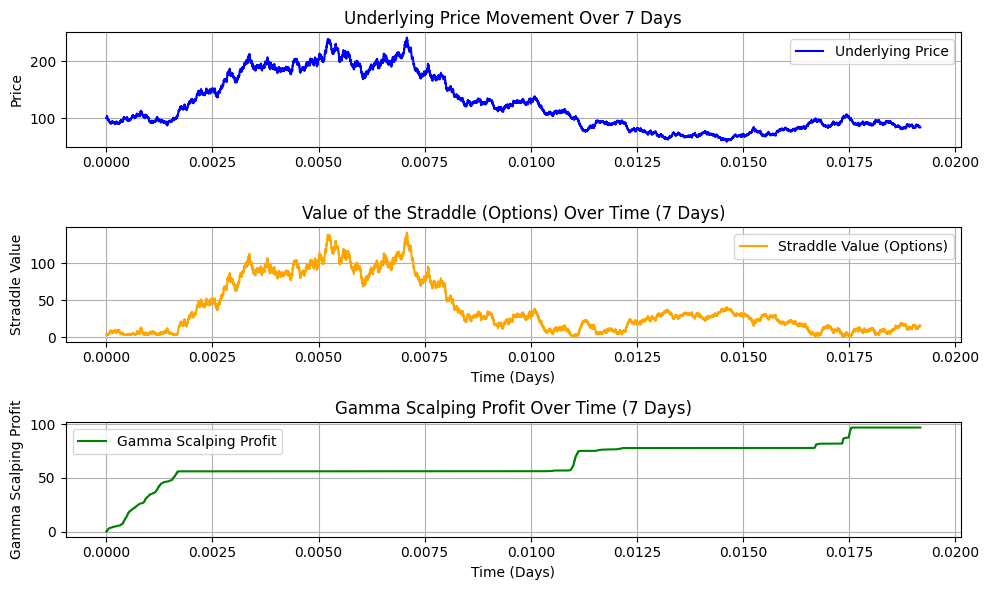

In [26]:
# Fix the incorrect usage of np.cdf to norm.cdf
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Add epsilon to avoid division by zero when T approaches zero
epsilon = 1e-6  # Small value to ensure T never reaches zero

# Black-Scholes formula for calculating the option price (with epsilon for T)
def black_scholes_price(S, K, T, r, sigma, option_type="call"):
    """Calculate the Black-Scholes price for a European call or put option."""
    T = max(T, epsilon)  # Ensure time-to-expiration is never zero
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    
    return price

# Set up the basic parameters for the 7-day straddle
S0 = 100  # Initial price of the underlying asset
K = 100   # Strike price (ATM)
T = 7 / 365  # 7 days to expiration
r = 0.01  # Risk-free rate
sigma = 0.3  # Volatility (30% annualized)
dt = 1 / (24 * 60)  # Time step in days (every minute)
n_steps = int(7 / dt)  # Total number of steps over 7 days

# Simulate the underlying price using GBM (Geometric Brownian Motion)
np.random.seed(42)  # For reproducibility
t = np.linspace(0, T, n_steps)
S = S0 * np.exp((r - 0.5 * sigma ** 2) * t + sigma * np.sqrt(dt) * np.random.randn(n_steps).cumsum())

# Calculate the initial value of the straddle (call + put)
initial_call_price = black_scholes_price(S0, K, T, r, sigma, option_type="call")
initial_put_price = black_scholes_price(S0, K, T, r, sigma, option_type="put")
initial_straddle_value = initial_call_price + initial_put_price

# Track the value of the straddle and the profit over time
straddle_value = np.zeros(n_steps)

# Simulate the straddle value and calculate the profit
for i in range(n_steps):
    t_remaining = T - t[i]
    # Calculate new call and put prices as the underlying price moves
    call_price = black_scholes_price(S[i], K, t_remaining, r, sigma, option_type="call")
    put_price = black_scholes_price(S[i], K, t_remaining, r, sigma, option_type="put")
    
    # Straddle value at this point in time
    straddle_value[i] = call_price + put_price

# Apply gamma scalping: capturing small profits from changes in delta and price movements

# Calculate straddle delta for gamma scalping (with epsilon for T)
def straddle_delta(S, K, T, r, sigma):
    T = max(T, epsilon)  # Ensure time-to-expiration is never zero
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    delta_call = norm.cdf(d1)
    delta_put = norm.cdf(d1) - 1
    return delta_call - abs(delta_put)

# Initialize variables for gamma scalping profit calculation
gamma_scalping_profit = np.zeros(n_steps)

# We will track profits by capturing small gains whenever the underlying price moves
for i in range(1, n_steps):
    t_remaining = T - t[i]
    
    # Calculate the straddle's delta at the current step
    current_delta = straddle_delta(S[i], K, t_remaining, r, sigma)
    previous_delta = straddle_delta(S[i-1], K, t_remaining, r, sigma)
    
    # Gamma scalping profits are captured when there's a change in delta (price movement)
    delta_change = current_delta - previous_delta
    
    # Capture the gamma scalping profit (difference in straddle value due to delta change)
    gamma_scalping_profit[i] = gamma_scalping_profit[i-1] + delta_change * (S[i] - S[i-1])

# Plot the results
plt.figure(figsize=(10, 6))

# Plot the underlying price
plt.subplot(3, 1, 1)
plt.plot(t, S, label='Underlying Price', color='blue')
plt.title('Underlying Price Movement Over 7 Days')
plt.ylabel('Price')
plt.legend()
plt.grid(True)

# Plot the straddle value over time
plt.subplot(3, 1, 2)
plt.plot(t, straddle_value, label='Straddle Value (Options)', color='orange')
plt.title('Value of the Straddle (Options) Over Time (7 Days)')
plt.xlabel('Time (Days)')
plt.ylabel('Straddle Value')
plt.legend()
plt.grid(True)

# Plot the gamma scalping profit over time
plt.subplot(3, 1, 3)
plt.plot(t, gamma_scalping_profit, label='Gamma Scalping Profit', color='green')
plt.title('Gamma Scalping Profit Over Time (7 Days)')
plt.xlabel('Time (Days)')
plt.ylabel('Gamma Scalping Profit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


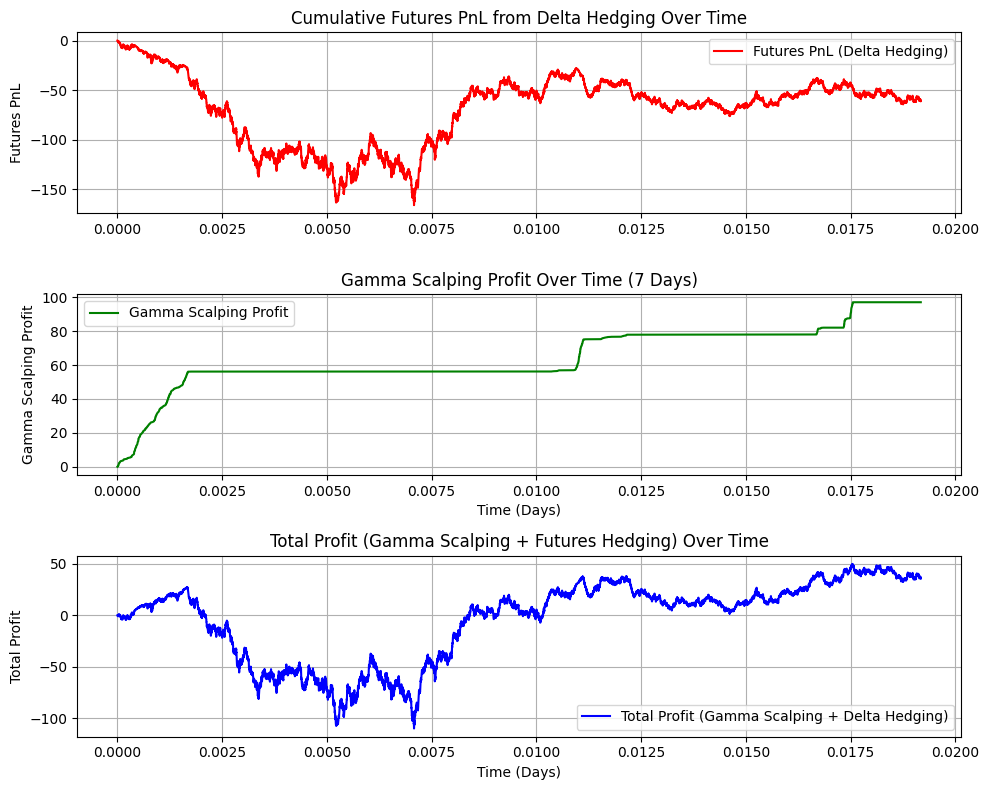

In [27]:
# Dynamic Delta Hedging: Adjusting the futures position to hedge the delta of the straddle

# Initialize variables for futures position and profit tracking
futures_position = 0
futures_pnl = np.zeros(n_steps)
cumulative_futures_pnl = np.zeros(n_steps)

# Simulate the delta hedging process with futures
for i in range(1, n_steps):
    t_remaining = T - t[i]
    
    # Calculate the delta of the straddle at the current step
    current_delta = straddle_delta(S[i], K, t_remaining, r, sigma)
    
    # Adjust the futures position to hedge the straddle's delta
    futures_trade_size = abs(current_delta - futures_position)  # Size of the trade needed to hedge delta
    futures_position = -current_delta  # Adjust futures to be delta-neutral
    
    # Calculate the PnL from the futures position (hedging)
    futures_pnl[i] = futures_position * (S[i] - S[i-1])
    
    # Accumulate the total PnL from futures
    cumulative_futures_pnl[i] = cumulative_futures_pnl[i-1] + futures_pnl[i]

# Combine the gamma scalping profit with futures PnL to get the total profit
total_profit = gamma_scalping_profit + cumulative_futures_pnl

# Plot the results
plt.figure(figsize=(10, 8))

# Plot the futures PnL over time
plt.subplot(3, 1, 1)
plt.plot(t, cumulative_futures_pnl, label='Futures PnL (Delta Hedging)', color='red')
plt.title('Cumulative Futures PnL from Delta Hedging Over Time')
plt.ylabel('Futures PnL')
plt.legend()
plt.grid(True)

# Plot the gamma scalping profit
plt.subplot(3, 1, 2)
plt.plot(t, gamma_scalping_profit, label='Gamma Scalping Profit', color='green')
plt.title('Gamma Scalping Profit Over Time (7 Days)')
plt.xlabel('Time (Days)')
plt.ylabel('Gamma Scalping Profit')
plt.legend()
plt.grid(True)

# Plot the total profit (Gamma Scalping + Futures PnL)
plt.subplot(3, 1, 3)
plt.plot(t, total_profit, label='Total Profit (Gamma Scalping + Delta Hedging)', color='blue')
plt.title('Total Profit (Gamma Scalping + Futures Hedging) Over Time')
plt.xlabel('Time (Days)')
plt.ylabel('Total Profit')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
